# Housing Affordability in England and Wales: Chapter 3 Data Analysis

This notebook performs the full Python-based data preparation and statistical analysis for the selected ONS workbook tabs:

- `1a`, `1b`, `1c`: country and region median house prices, workplace earnings, and affordability ratios
- `5a`, `5b`, `5c`: local authority median house prices, workplace earnings, and affordability ratios

The workflow follows the Chapter 3 methodology: data source review, cleaning, consistency checks, reshaping, merging, descriptive statistics, regional comparison, Pearson correlation, multiple linear regression, and diagnostic checks.

In [18]:
# Core libraries used for the full analysis.
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy import stats

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="Set2")

DATA_FILE = Path(r"aff1ratioofhousepricetoworkplacebasedearnings.xlsx")
assert DATA_FILE.exists(), f"Dataset not found: {DATA_FILE}"

print(f"Dataset loaded from: {DATA_FILE}")

Dataset loaded from: aff1ratioofhousepricetoworkplacebasedearnings.xlsx


## 1. Data Source and Selected Sheets

The analysis uses the official ONS workbook on the ratio of house prices to workplace-based earnings. Regional sheets are used to describe broad geographic patterns, while local-authority sheets provide detailed observations across place and time.

Median house price and workplace earnings remain important descriptive variables and are also examined using Pearson correlation. However, the regression stage focuses directly on the **affordability ratio**, which is the study's principal measure of purchase affordability.


In [19]:
import openpyxl

wb = openpyxl.load_workbook(DATA_FILE, read_only=True, data_only=True)
selected_sheets = ["1a", "1b", "1c", "5a", "5b", "5c"]

sheet_summary = []
for sheet in selected_sheets:
    ws = wb[sheet]
    sheet_summary.append({
        "sheet": sheet,
        "title": ws.cell(1, 1).value,
        "rows": ws.max_row,
        "columns": ws.max_column
    })

sheet_summary_df = pd.DataFrame(sheet_summary)
display(sheet_summary_df)

,sheet,title,rows,columns
0,1a,Table 1a - Median house price by country and r...,14,31
1,1b,Table 1b - Median gross annual workplace-based...,14,31
2,1c,Table 1c - Ratio of median house price to medi...,14,32
3,5a,Table 5a - Median house price by local authori...,321,33
4,5b,Table 5b - Median gross annual workplace-based...,321,34
5,5c,Table 5c - Ratio of median house price to medi...,321,34


## 2. Helper Functions for Cleaning and Reshaping

ONS sheets are in wide format, with one column per year. These functions clean the sheets, extract year values from column names, convert suppressed values such as `[x]` into missing values, and reshape each table into long format.


In [20]:
def extract_year(label):
    """Extract a four-digit year from a column label such as 'Year ending Sep 2025' or '2025'."""
    match = re.search(r"(19|20)\d{2}", str(label))
    return int(match.group(0)) if match else None


def clean_numeric(series):
    """Convert ONS numeric columns to float, treating suppression markers as missing."""
    return (
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("£", "", regex=False)
        .str.strip()
        .replace({"[x]": np.nan, "nan": np.nan, "None": np.nan, "": np.nan})
        .pipe(pd.to_numeric, errors="coerce")
    )


def read_ons_sheet(sheet_name, metric_name, geography_level):
    """Read, clean and reshape one selected ONS sheet into long format."""
    raw = pd.read_excel(DATA_FILE, sheet_name=sheet_name, header=1)
    raw = raw.dropna(axis=1, how="all")
    raw = raw.loc[:, ~raw.columns.astype(str).str.contains("^Unnamed")]

    year_columns = [col for col in raw.columns if extract_year(col) is not None]

    if geography_level == "regional":
        id_columns = ["Code", "Name"]
    elif geography_level == "local_authority":
        id_columns = [
            "Country/Region code",
            "Country/Region name",
            "Local authority code",
            "Local authority name",
        ]
    else:
        raise ValueError("geography_level must be 'regional' or 'local_authority'")

    long_df = raw[id_columns + year_columns].melt(
        id_vars=id_columns,
        value_vars=year_columns,
        var_name="year_label",
        value_name=metric_name,
    )
    long_df["year"] = long_df["year_label"].apply(extract_year)
    long_df[metric_name] = clean_numeric(long_df[metric_name])
    long_df = long_df.drop(columns=["year_label"])

    return long_df

## 3. Import Selected Sheets

`1a-1c` are used for regional descriptive context. `5a-5c` are used as the main detailed analytical dataset because they provide local authority observations and already contain region identifiers.


In [21]:
regional_price = read_ons_sheet("1a", "median_house_price", "regional")
regional_earnings = read_ons_sheet("1b", "workplace_earnings", "regional")
regional_ratio = read_ons_sheet("1c", "affordability_ratio", "regional")

local_price = read_ons_sheet("5a", "median_house_price", "local_authority")
local_earnings = read_ons_sheet("5b", "workplace_earnings", "local_authority")
local_ratio = read_ons_sheet("5c", "affordability_ratio", "local_authority")

print("Regional price shape:", regional_price.shape)
print("Regional earnings shape:", regional_earnings.shape)
print("Regional ratio shape:", regional_ratio.shape)
print("Local price shape:", local_price.shape)
print("Local earnings shape:", local_earnings.shape)
print("Local ratio shape:", local_ratio.shape)

Regional price shape: (348, 4)
Regional earnings shape: (348, 4)
Regional ratio shape: (348, 4)
Local price shape: (9222, 6)
Local earnings shape: (9222, 6)
Local ratio shape: (9222, 6)


## 4. Merge Variables into Analytical Datasets

The variables are merged by geography and year. The regional dataset is used for broad descriptive and trend analysis. The local-authority dataset provides the larger panel of observations used for detailed rankings, correlation and the revised affordability-ratio regression models.


In [22]:
regional = (
    regional_price
    .merge(regional_earnings, on=["Code", "Name", "year"], how="inner")
    .merge(regional_ratio, on=["Code", "Name", "year"], how="inner")
    .rename(columns={"Code": "region_code", "Name": "region"})
)

# Remove aggregate rows from the regional analytical dataset to avoid double counting.
regional = regional[~regional["region"].isin(["England and Wales", "England"])].copy()

local = (
    local_price
    .merge(local_earnings, on=[
        "Country/Region code", "Country/Region name",
        "Local authority code", "Local authority name", "year"
    ], how="inner")
    .merge(local_ratio, on=[
        "Country/Region code", "Country/Region name",
        "Local authority code", "Local authority name", "year"
    ], how="inner")
    .rename(columns={
        "Country/Region code": "region_code",
        "Country/Region name": "region",
        "Local authority code": "local_authority_code",
        "Local authority name": "local_authority",
    })
)

print("Merged regional dataset:", regional.shape)
print("Merged local authority dataset:", local.shape)
display(regional.head())
display(local.head())

Merged regional dataset: (290, 6)
Merged local authority dataset: (9222, 8)


,region_code,region,median_house_price,year,workplace_earnings,affordability_ratio
2,W92000004,Wales,47000.0,1997,15679,3.00
3,E12000001,North East,46500.0,1997,15622,2.98
4,E12000002,North West,48500.0,1997,16107,3.01
5,E12000003,Yorkshire and The Humber,48500.0,1997,15538,3.12
6,E12000004,East Midlands,49950.0,1997,15773,3.17


,region_code,region,local_authority_code,local_authority,median_house_price,year,workplace_earnings,affordability_ratio
0,E12000001,North East,E06000001,Hartlepool,41500,1997,15747.0,2.64
1,E12000001,North East,E06000002,Middlesbrough,45000,1997,15914.0,2.83
2,E12000001,North East,E06000003,Redcar and Cleveland,44995,1997,19206.0,2.34
3,E12000001,North East,E06000004,Stockton-on-Tees,49950,1997,16838.0,2.97
4,E12000001,North East,E06000005,Darlington,46950,1997,15424.0,3.04


## 5. Cleaning and Consistency Checks

This section documents missing values, duplicate observations, year coverage, and a recalculation check for the affordability ratio. The ratio should approximately equal median house price divided by workplace earnings.


In [23]:
def quality_report(df, keys, name):
    duplicate_count = df.duplicated(keys).sum()
    missing = df[["median_house_price", "workplace_earnings", "affordability_ratio"]].isna().sum()
    report = pd.DataFrame({
        "check": [
            "rows",
            "unique geographies",
            "year minimum",
            "year maximum",
            "duplicate key rows",
            "missing median_house_price",
            "missing workplace_earnings",
            "missing affordability_ratio",
        ],
        "value": [
            len(df),
            df[keys[0]].nunique(),
            int(df["year"].min()),
            int(df["year"].max()),
            int(duplicate_count),
            int(missing["median_house_price"]),
            int(missing["workplace_earnings"]),
            int(missing["affordability_ratio"]),
        ]
    })
    display(Markdown(f"### {name} quality report"))
    display(report)

quality_report(regional, ["region_code", "year"], "Regional dataset")
quality_report(local, ["local_authority_code", "year"], "Local authority dataset")

# Recalculate affordability ratio to check whether published ratio aligns with price / earnings.
local["recalculated_ratio"] = local["median_house_price"] / local["workplace_earnings"]
local["ratio_difference"] = local["affordability_ratio"] - local["recalculated_ratio"]

ratio_check = local[["affordability_ratio", "recalculated_ratio", "ratio_difference"]].describe().round(4)
display(Markdown("### Ratio recalculation check: local authority dataset"))
display(ratio_check)

### Regional dataset quality report

,check,value
0,rows,290
1,unique geographies,10
2,year minimum,1997
3,year maximum,2025
4,duplicate key rows,0
5,missing median_house_price,0
6,missing workplace_earnings,0
7,missing affordability_ratio,0


### Local authority dataset quality report

,check,value
0,rows,9222
1,unique geographies,318
2,year minimum,1997
3,year maximum,2025
4,duplicate key rows,0
5,missing median_house_price,0
6,missing workplace_earnings,170
7,missing affordability_ratio,170


### Ratio recalculation check: local authority dataset

,affordability_ratio,recalculated_ratio,ratio_difference
count,9052.0000,9052.0000,9052.0000
mean,7.3795,7.3794,0.0001
std,3.2329,3.2329,0.0029
min,1.6600,1.6638,-0.0050
25%,5.2300,5.2261,-0.0025
50%,6.8500,6.8497,0.0001
75%,9.0200,9.0185,0.0026
max,43.9700,43.9714,0.0050


## 6. Final Analysis Dataset

Observations with missing house price, workplace earnings, affordability ratio, region or year are removed from the relevant statistical analysis. The regression models use the ONS affordability ratio as the dependent variable and use year and region as explanatory variables.

House price and earnings are deliberately excluded from the affordability-ratio regression because the affordability ratio is calculated from those two variables. Including them as predictors would make the model circular.


In [24]:
analysis_df = local.dropna(subset=[
    "median_house_price",
    "workplace_earnings",
    "affordability_ratio",
    "region",
    "year",
]).copy()

analysis_df["year_centered"] = analysis_df["year"] - analysis_df["year"].min()

print("Rows before dropping missing values:", len(local))
print("Rows after dropping missing values:", len(analysis_df))
print("Number of local authorities:", analysis_df["local_authority"].nunique())
print("Number of regions/countries:", analysis_df["region"].nunique())
print("Years covered:", analysis_df["year"].min(), "to", analysis_df["year"].max())

display(analysis_df.head())

Rows before dropping missing values: 9222
Rows after dropping missing values: 9052
Number of local authorities: 318
Number of regions/countries: 10
Years covered: 1997 to 2025


,region_code,region,local_authority_code,local_authority,median_house_price,year,workplace_earnings,affordability_ratio,recalculated_ratio,ratio_difference,year_centered
0,E12000001,North East,E06000001,Hartlepool,41500,1997,15747.0,2.64,2.635423,0.004577,0
1,E12000001,North East,E06000002,Middlesbrough,45000,1997,15914.0,2.83,2.827699,0.002301,0
2,E12000001,North East,E06000003,Redcar and Cleveland,44995,1997,19206.0,2.34,2.342757,-0.002757,0
3,E12000001,North East,E06000004,Stockton-on-Tees,49950,1997,16838.0,2.97,2.966504,0.003496,0
4,E12000001,North East,E06000005,Darlington,46950,1997,15424.0,3.04,3.043957,-0.003957,0


## 7. Descriptive Statistics

Chapter 3 states that median house prices, workplace earnings, and affordability ratios should be summarised using descriptive statistics. The statistics below support comparison across England and Wales and across regions.


In [25]:
overall_descriptives = analysis_df[[
    "median_house_price",
    "workplace_earnings",
    "affordability_ratio",
]].describe().T.round(2)

display(Markdown("### Overall descriptive statistics"))
display(overall_descriptives)

regional_descriptives = (
    analysis_df
    .groupby("region")[["median_house_price", "workplace_earnings", "affordability_ratio"]]
    .agg(["mean", "median", "min", "max", "std"])
    .round(2)
)

display(Markdown("### Regional descriptive statistics"))
display(regional_descriptives)

### Overall descriptive statistics

,count,mean,std,min,25%,50%,75%,max
median_house_price,9052.0,201018.65,128945.13,30000.00,120000.00,172437.50,250000.00,1450000.00
workplace_earnings,9052.0,25649.00,6633.19,11166.00,20873.50,24991.00,29603.50,68663.00
affordability_ratio,9052.0,7.38,3.23,1.66,5.23,6.85,9.02,43.97


### Regional descriptive statistics

median_house_price                                      workplace_earnings                                     affordability_ratio  \
                                       mean    median    min      max        std               mean   median      min      max      std                mean   
region                                                                                                                                                        
East Midlands                     149708.49  144998.0  39000   356000   65727.13           23700.97  23340.0  12783.0  41924.0  5468.30                6.10   
East of England                   223467.64  200000.0  42500   650000  110739.91           26140.74  25689.0  13660.0  50931.0  6147.64                8.15   
London                            357744.97  303000.0  52000  1450000  217964.22           31085.60  30097.0  14693.0  68663.0  8276.73               10.92   
North East                        117279.50  122997.5  41500   210000   39760.34           23756.65  23937.0  14453.0  37005.0  4874.10                4.83   
North West                        130132.82  125000.0  30000   372500   58120.78           24069.48  23562.0  13483.0  49351.0  5762.35                5.20   
South East                        246079.35  235000.0  46000   675000  114057.65           27186.54  26720.0  11709.0  49889.0  6651.89                8.71   
South West                        201047.23  195000.0  46500   455000   80060.64           24232.25  23784.5  11166.0  42267.0  5933.54                8.13   
Wales                             128978.68  132375.0  30000   325000   56823.36           23215.71  22837.5  12386.0  39426.0  5519.48                5.39   
West Midlands                     161101.01  152000.0  33000   375000   71447.48           24166.87  23582.0  13785.0  49476.0  5674.10                6.44   
Yorkshire and The Humber          125990.14  124995.0  34500   307500   54386.71           24080.76  23952.0  14813.0  39337.0  5108.61                5.04   

                                                    
                         median   min    max   std  
region                                              
East Midlands              6.09  2.23  12.63  1.82  
East of England            7.99  2.51  18.29  2.67  
London                    10.14  2.58  43.97  5.11  
North East                 5.00  2.12   7.04  1.07  
North West                 5.24  1.66  10.87  1.53  
South East                 8.64  2.95  19.35  2.73  
South West                 8.32  2.90  24.94  2.38  
Wales                      5.44  1.92  10.25  1.72  
West Midlands              6.32  2.27  12.02  1.96  
Yorkshire and The Humber   5.14  2.16   9.03  1.48

## 8. Regional Comparison and Ranking

Higher affordability ratios indicate worse purchase affordability. The ranking below identifies the places and regions with the highest and lowest affordability pressure.


In [26]:
latest_year = int(analysis_df["year"].max())
latest = analysis_df[analysis_df["year"] == latest_year].copy()

region_latest = (
    latest.groupby("region", as_index=False)
    .agg(
        median_house_price=("median_house_price", "median"),
        workplace_earnings=("workplace_earnings", "median"),
        affordability_ratio=("affordability_ratio", "median"),
        local_authorities=("local_authority", "nunique"),
    )
    .sort_values("affordability_ratio", ascending=False)
    .round(2)
)

display(Markdown(f"### Regional median affordability in {latest_year}"))
display(region_latest)

top_10_least_affordable = latest.sort_values("affordability_ratio", ascending=False).head(10)[[
    "region", "local_authority", "median_house_price", "workplace_earnings", "affordability_ratio"
]].round(2)

top_10_most_affordable = latest.sort_values("affordability_ratio", ascending=True).head(10)[[
    "region", "local_authority", "median_house_price", "workplace_earnings", "affordability_ratio"
]].round(2)

display(Markdown(f"### Top 10 least affordable local authorities in {latest_year}"))
display(top_10_least_affordable)

display(Markdown(f"### Top 10 most affordable local authorities in {latest_year}"))
display(top_10_most_affordable)

### Regional median affordability in 2025

,region,median_house_price,workplace_earnings,affordability_ratio,local_authorities
2,London,538500.0,42346.0,12.22,33
5,South East,382250.0,39060.0,9.96,64
1,East of England,345000.0,37704.0,9.31,45
6,South West,308624.0,35704.0,8.34,26
8,West Midlands,257500.0,35130.5,7.12,30
0,East Midlands,244922.0,34868.0,7.02,35
4,North West,207875.0,35376.0,5.98,35
7,Wales,206750.0,35577.5,5.90,22
9,Yorkshire and The Humber,191996.0,34966.0,5.58,15
3,North East,165000.0,33920.0,4.84,12


### Top 10 least affordable local authorities in 2025

,region,local_authority,median_house_price,workplace_earnings,affordability_ratio
9095,London,Kensington and Chelsea,1150000,45600.0,25.22
9102,London,Richmond upon Thames,720000,41037.0,17.55
9108,London,Westminster,865000,53923.0,16.04
9155,South East,Elmbridge,650000,41309.0,15.74
9070,East of England,St Albans,630000,41967.0,15.01
9078,London,Barnet,569062,38294.0,14.86
9107,London,Wandsworth,632501,43035.0,14.70
9080,London,Brent,555000,38311.0,14.49
9082,London,Camden,770000,53577.0,14.37
9106,London,Waltham Forest,538010,37503.0,14.35


### Top 10 most affordable local authorities in 2025

,region,local_authority,median_house_price,workplace_earnings,affordability_ratio
8927,North West,Hyndburn,135000,33089.0,4.08
8951,Yorkshire and The Humber,"Kingston upon Hull, City of",140000,33946.0,4.12
8922,North West,Cumberland,177500,42808.0,4.15
8919,North West,Blackpool,136000,32553.0,4.18
8924,North West,Burnley,130000,31087.0,4.18
8909,North East,County Durham,143000,32945.0,4.34
9216,Wales,Blaenau Gwent,140000,32294.0,4.34
9210,Wales,Neath Port Talbot,164998,37417.0,4.41
9003,West Midlands,Stoke-on-Trent,154250,34744.0,4.44
8905,North East,Middlesbrough,153500,34000.0,4.51


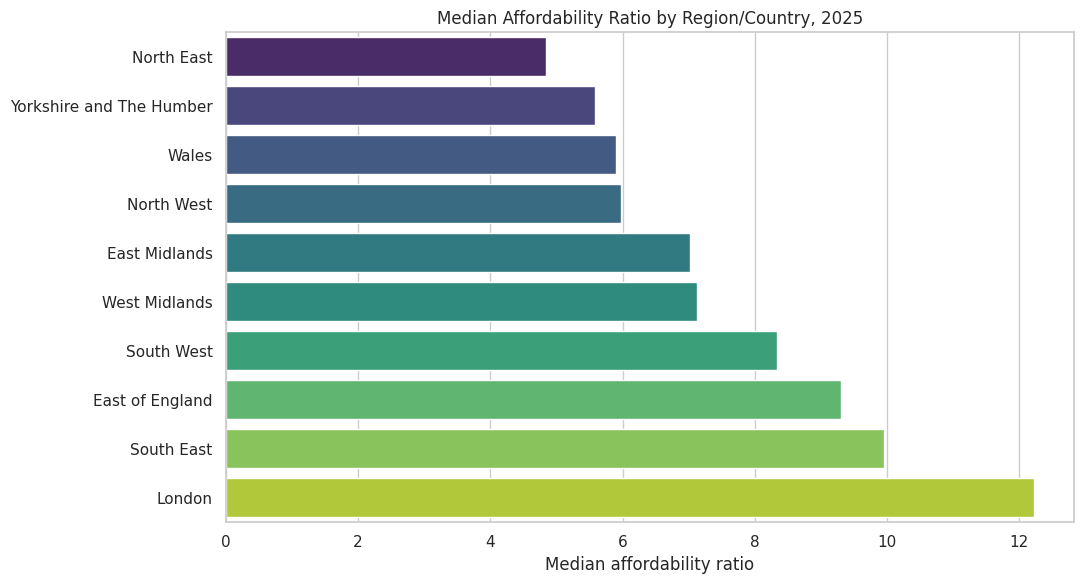

In [27]:
plt.figure(figsize=(11, 6))
sns.barplot(
    data=region_latest,
    y="region",
    x="affordability_ratio",
    order=region_latest.sort_values("affordability_ratio", ascending=True)["region"],
    palette="viridis",
)
plt.title(f"Median Affordability Ratio by Region/Country, {latest_year}")
plt.xlabel("Median affordability ratio")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 9. Long-Term Regional Trends

The line chart uses the regional sheets (`1a-1c`) to show long-term affordability patterns across regions from 1997 to 2025.


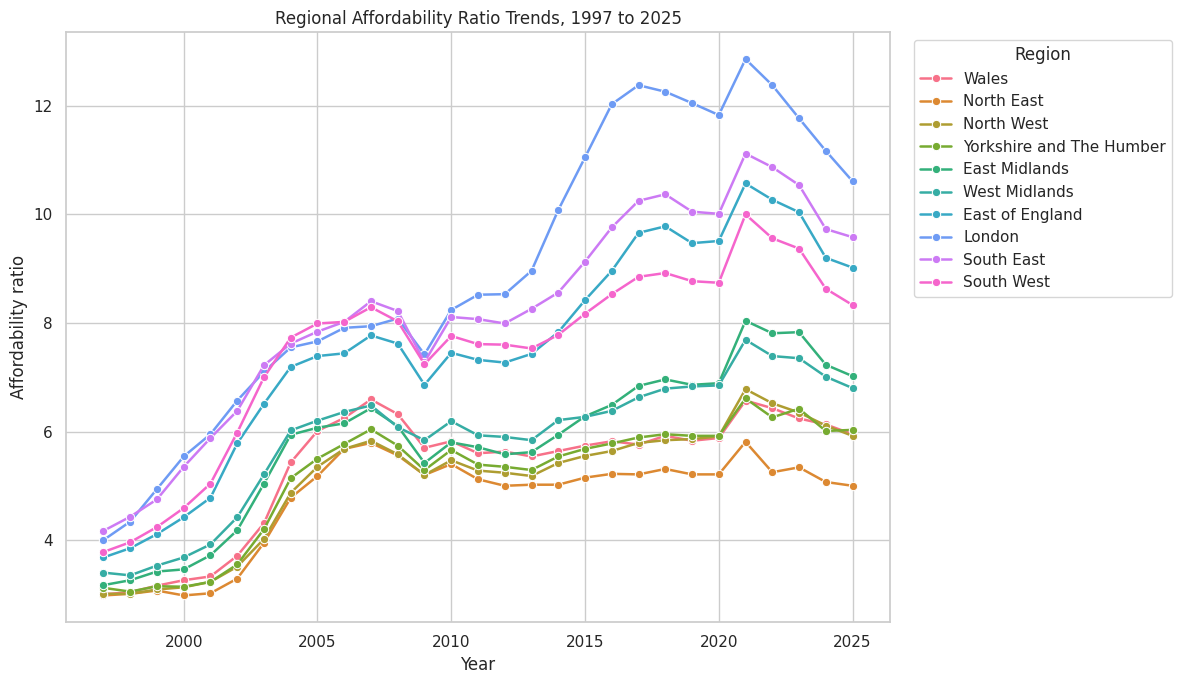

In [28]:
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=regional,
    x="year",
    y="affordability_ratio",
    hue="region",
    marker="o",
    linewidth=1.8,
)
plt.title("Regional Affordability Ratio Trends, 1997 to 2025")
plt.xlabel("Year")
plt.ylabel("Affordability ratio")
plt.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 10. Pearson Correlation

Pearson correlation tests the strength and direction of the relationship between median house prices and workplace earnings. This is an association test and should not be interpreted as proof of causation.


,relationship,pearson_r,p_value,n
0,Median house price vs workplace earnings,0.776563,0.0,9052


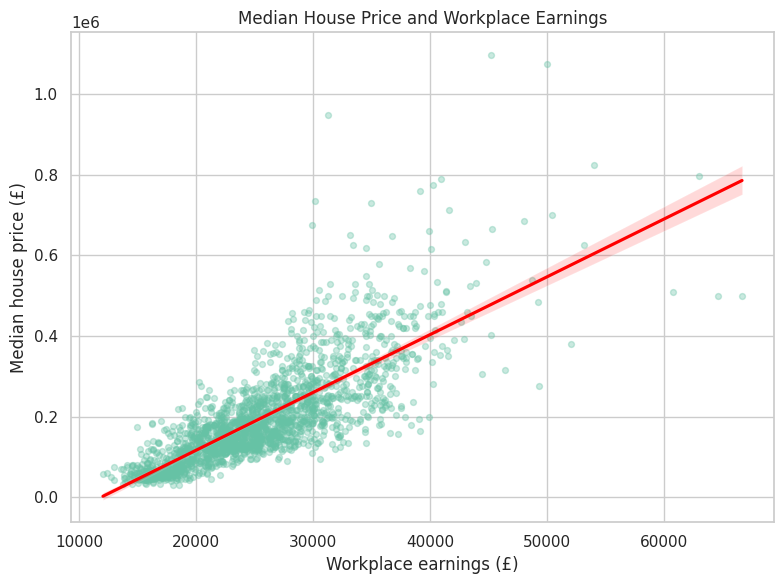

In [29]:
corr_r, corr_p = stats.pearsonr(analysis_df["median_house_price"], analysis_df["workplace_earnings"])

corr_table = pd.DataFrame({
    "relationship": ["Median house price vs workplace earnings"],
    "pearson_r": [corr_r],
    "p_value": [corr_p],
    "n": [len(analysis_df)]
}).round(6)

display(corr_table)

plt.figure(figsize=(8, 6))
sns.regplot(
    data=analysis_df.sample(min(2000, len(analysis_df)), random_state=42),
    x="workplace_earnings",
    y="median_house_price",
    scatter_kws={"alpha": 0.35, "s": 18},
    line_kws={"color": "red"},
)
plt.title("Median House Price and Workplace Earnings")
plt.xlabel("Workplace earnings (£)")
plt.ylabel("Median house price (£)")
plt.tight_layout()
plt.show()

## 11. Affordability Regression: Competing Model Specifications




In [30]:
def fit_ols_model(df, y_col, X_df, model_name):
    """Fit OLS using numpy and return coefficients, fit statistics and diagnostics inputs."""
    # Combine y and X, then drop NaNs. This preserves the original index.
    combined_df = pd.concat([df[[y_col]], X_df], axis=1).dropna()

    y = combined_df[y_col].astype(float).to_numpy()
    X = combined_df.drop(columns=[y_col]).astype(float)

    if "Intercept" not in X.columns:
        X.insert(0, "Intercept", 1.0)

    X_mat = X.to_numpy(dtype=float)
    beta = np.linalg.lstsq(X_mat, y, rcond=None)[0]
    fitted = X_mat @ beta
    residuals = y - fitted

    n = len(y)
    k = X_mat.shape[1]
    sse = np.sum(residuals ** 2)
    mse = sse / max(n - k, 1)
    rmse = np.sqrt(np.mean(residuals ** 2))

    y_mean = y.mean()
    sst = np.sum((y - y_mean) ** 2)
    r2 = 1 - (sse / sst)
    adj_r2 = 1 - (1 - r2) * (n - 1) / max(n - k, 1)

    # Information criteria for model comparison
    sigma2_mle = sse / n
    loglik = -0.5 * n * (np.log(2 * np.pi) + np.log(sigma2_mle) + 1)
    aic = 2 * k - 2 * loglik
    bic = np.log(n) * k - 2 * loglik

    xtx_inv = np.linalg.pinv(X_mat.T @ X_mat)
    cov_beta = mse * xtx_inv
    se = np.sqrt(np.diag(cov_beta))
    t_stats = beta / se
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=max(n-k, 1)))

    crit = stats.t.ppf(0.975, df=max(n-k, 1))
    ci_low = beta - crit * se
    ci_high = beta + crit * se

    coef_table = pd.DataFrame({
        "variable": X.columns,
        "coefficient": beta,
        "std_error": se,
        "t_stat": t_stats,
        "p_value": p_values,
        "ci_95_low": ci_low,
        "ci_95_high": ci_high,
    })

    fit = {
        "model": model_name,
        "n": n,
        "parameters": k,
        "r_squared": r2,
        "adjusted_r_squared": adj_r2,
        "rmse": rmse,
        "aic": aic,
        "bic": bic,
    }

    return {
        "name": model_name,
        "coef": coef_table,
        "fit": fit,
        "fitted": fitted,
        "residuals": residuals,
        "X": X,
        "y": y,
    }


model_df = analysis_df.copy()
model_df["year_centered"] = model_df["year"] - model_df["year"].min()

region_dummies = pd.get_dummies(
    model_df["region"],
    prefix="region",
    drop_first=True,
    dtype=float
)

# Model A: time trend only
X_A = pd.DataFrame({
    "year_centered": model_df["year_centered"].astype(float)
})
model_A = fit_ols_model(
    model_df, "affordability_ratio", X_A, "Model A: Year only"
)

# Model B: regional differences only
X_B = region_dummies.copy()
model_B = fit_ols_model(
    model_df, "affordability_ratio", X_B, "Model B: Region only"
)

# Model C: additive time + region model
X_C = pd.concat(
    [model_df[["year_centered"]].astype(float), region_dummies],
    axis=1
)
model_C = fit_ols_model(
    model_df, "affordability_ratio", X_C, "Model C: Year + Region"
)

# Model D: allow each region to have a different time trend
interaction_terms = pd.DataFrame(index=model_df.index)
for col in region_dummies.columns:
    interaction_terms[f"{col}_x_year"] = (
        region_dummies[col].astype(float) * model_df["year_centered"].astype(float)
    )

X_D = pd.concat(
    [
        model_df[["year_centered"]].astype(float),
        region_dummies,
        interaction_terms
    ],
    axis=1
)
model_D = fit_ols_model(
    model_df,
    "affordability_ratio",
    X_D,
    "Model D: Year + Region + Year×Region"
)

models = [model_A, model_B, model_C, model_D]

model_comparison = pd.DataFrame([m["fit"] for m in models])

display(Markdown("### Table: Comparison of alternative affordability models"))
display(
    model_comparison[
        ["model", "n", "parameters", "r_squared",
         "adjusted_r_squared", "rmse", "aic", "bic"]
    ].round(4)
)


### Table: Comparison of alternative affordability models

,model,n,parameters,r_squared,adjusted_r_squared,rmse,aic,bic
0,Model A: Year only,9052,2,0.2356,0.2355,2.8264,44502.3158,44516.5373
1,Model B: Region only,9052,10,0.3227,0.3220,2.6605,43423.5325,43494.6399
2,Model C: Year + Region,9052,11,0.5619,0.5614,2.1396,39480.9487,39559.1669
3,Model D: Year + Region + Year×Region,9052,20,0.6089,0.6080,2.0218,38473.2521,38615.4669


### 11.1 Model Selection

Model selection should not be based on one statistic alone. A stronger model should generally have:

- higher adjusted R²;
- lower RMSE;
- lower AIC and BIC;
- a specification that is substantively meaningful for the research question;
- acceptable residual diagnostics.

Model D is more flexible because it allows affordability trends to differ by region, but it should only be preferred if the improvement in fit is sufficient to justify the additional interaction terms.


In [31]:
comparison = model_comparison.copy()

best_adj = comparison.loc[comparison["adjusted_r_squared"].idxmax(), "model"]
best_rmse = comparison.loc[comparison["rmse"].idxmin(), "model"]
best_aic = comparison.loc[comparison["aic"].idxmin(), "model"]
best_bic = comparison.loc[comparison["bic"].idxmin(), "model"]

print("Best adjusted R²:", best_adj)
print("Lowest RMSE:", best_rmse)
print("Lowest AIC:", best_aic)
print("Lowest BIC:", best_bic)

# Use BIC as the primary parsimony criterion; if tied conceptually,
# discuss adjusted R²/RMSE and interpretability in the dissertation.
preferred_name = best_bic
preferred_model = next(m for m in models if m["name"] == preferred_name)

display(Markdown("### Preferred model coefficient table"))
display(preferred_model["coef"].round(4))

print(
    "\nInterpretation rule: positive coefficients indicate higher affordability ratios "
    "(poorer purchase affordability), while negative coefficients indicate lower ratios "
    "(better relative purchase affordability), holding the other included terms constant."
)


Best adjusted R²: Model D: Year + Region + Year×Region
Lowest RMSE: Model D: Year + Region + Year×Region
Lowest AIC: Model D: Year + Region + Year×Region
Lowest BIC: Model D: Year + Region + Year×Region


### Preferred model coefficient table

,variable,coefficient,std_error,t_stat,p_value,ci_95_low,ci_95_high
0,Intercept,4.0534,0.1260,32.1645,0.0000,3.8063,4.3004
1,year_centered,0.1447,0.0077,18.8295,0.0000,0.1296,0.1597
2,region_East of England,0.8013,0.1707,4.6957,0.0000,0.4668,1.1359
3,region_London,1.4370,0.1793,8.0146,0.0000,1.0855,1.7885
4,region_North East,-0.3814,0.2617,-1.4573,0.1451,-0.8945,0.1316
5,region_North West,-0.4584,0.1799,-2.5487,0.0108,-0.8109,-0.1058
6,region_South East,1.4473,0.1558,9.2870,0.0000,1.1418,1.7528
7,region_South West,1.7075,0.1978,8.6305,0.0000,1.3196,2.0953
8,region_Wales,-0.1595,0.2007,-0.7946,0.4269,-0.5529,0.2340
9,region_West Midlands,0.4567,0.1852,2.4656,0.0137,0.0936,0.8197



Interpretation rule: positive coefficients indicate higher affordability ratios (poorer purchase affordability), while negative coefficients indicate lower ratios (better relative purchase affordability), holding the other included terms constant.


### 11.2 What the Models Tell Us About Affordability

These models directly analyse the dissertation's affordability measure.

- Model A tests whether purchase affordability has changed systematically over the 1997–2025 period.
- Model B tests whether persistent differences exist between regions.
- Model C tests whether regional differences remain after accounting for the overall time trend.
- Model D tests whether the direction or speed of the affordability trend differs between regions.

This provides a clearer link between the inferential analysis and the research topic than a model whose dependent variable is median house price.


## 12. Regression Diagnostics for the Preferred Affordability Model


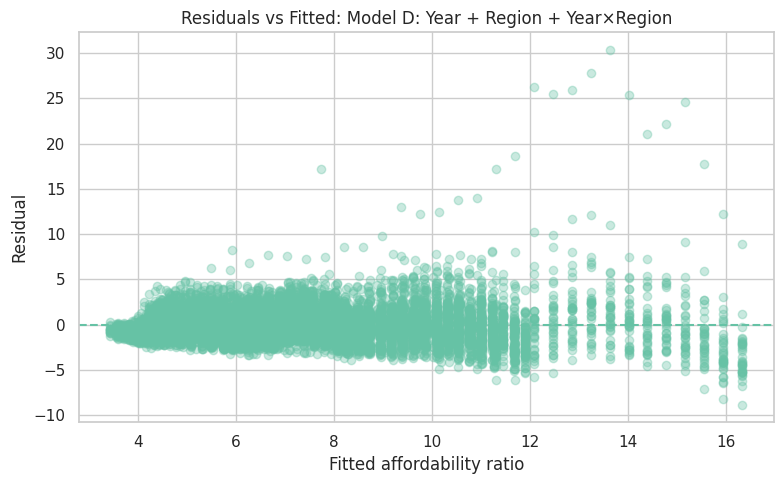

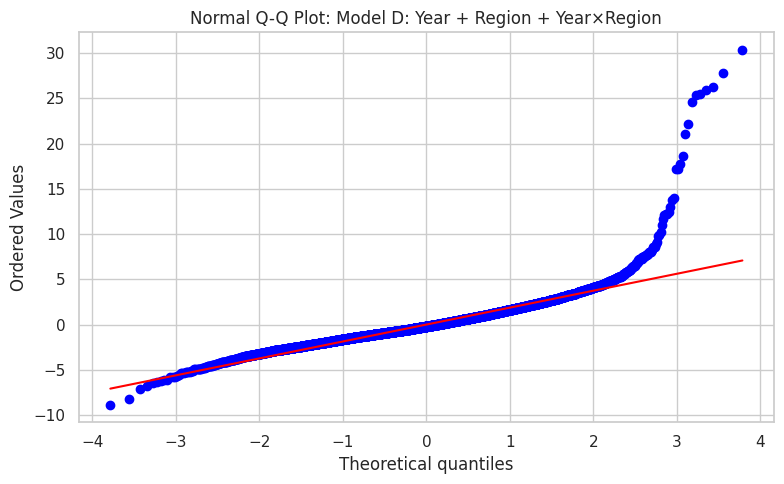

Residual mean: -0.0
Residual standard deviation: 2.0219


In [32]:
residuals = preferred_model["residuals"]
fitted = preferred_model["fitted"]
X_pref = preferred_model["X"]
y_pref = preferred_model["y"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(fitted, residuals, alpha=0.35)
ax.axhline(0, linestyle="--")
ax.set_xlabel("Fitted affordability ratio")
ax.set_ylabel("Residual")
ax.set_title(f"Residuals vs Fitted: {preferred_model['name']}")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title(f"Normal Q-Q Plot: {preferred_model['name']}")
plt.tight_layout()
plt.show()

print("Residual mean:", round(float(np.mean(residuals)), 6))
print("Residual standard deviation:", round(float(np.std(residuals, ddof=1)), 4))


### 12.1 Multicollinearity Check

Variance Inflation Factors (VIFs) are reported for the preferred specification. Interaction models naturally create more correlation among predictors, so VIF values should be interpreted alongside the model's substantive value rather than mechanically.


In [33]:
def calculate_vif(X_df):
    rows = []
    cols = [c for c in X_df.columns if c != "Intercept"]

    for target in cols:
        y_vif = X_df[target].astype(float).to_numpy()
        other_cols = [c for c in cols if c != target]

        if not other_cols:
            rows.append({"variable": target, "VIF": 1.0})
            continue

        X_other = X_df[other_cols].astype(float).copy()
        X_other.insert(0, "Intercept", 1.0)
        Xmat = X_other.to_numpy()

        beta = np.linalg.lstsq(Xmat, y_vif, rcond=None)[0]
        pred = Xmat @ beta

        sse = np.sum((y_vif - pred) ** 2)
        sst = np.sum((y_vif - y_vif.mean()) ** 2)

        if sst == 0:
            vif = np.inf
        else:
            r2 = 1 - sse / sst
            vif = np.inf if r2 >= 0.999999 else 1 / (1 - r2)

        rows.append({"variable": target, "VIF": vif})

    return pd.DataFrame(rows).sort_values("VIF", ascending=False)

vif_table = calculate_vif(X_pref)
display(vif_table.round(3))


,variable,VIF
14,region_South East_x_year,9.269
0,year_centered,8.987
5,region_South East,8.743
10,region_East of England_x_year,8.118
1,region_East of England,7.715
13,region_North West_x_year,7.224
4,region_North West,6.968
11,region_London_x_year,6.886
2,region_London,6.716
17,region_West Midlands_x_year,6.700


### 12.2 Influence Check

Cook's distance is calculated to identify observations that have unusually large influence on the preferred model. Influential observations are not automatically removed; they are identified and discussed because very high-affordability local authorities may be substantively important rather than data errors.


In [34]:
Xmat = X_pref.to_numpy(dtype=float)
n, k = Xmat.shape
mse = np.sum(residuals ** 2) / max(n-k, 1)

hat = np.sum((Xmat @ np.linalg.pinv(Xmat.T @ Xmat)) * Xmat, axis=1)
cooks_d = (residuals ** 2 / (k * mse)) * (hat / np.maximum((1-hat) ** 2, 1e-12))

influence_df = model_df.loc[
    preferred_model["X"].index,
    ["region", "local_authority", "year", "affordability_ratio"]
].copy()

# Align lengths safely if rows were dropped inside fitting
influence_df = influence_df.iloc[:len(cooks_d)].copy()
influence_df["cooks_distance"] = cooks_d

threshold = 4 / len(cooks_d)
print("Rule-of-thumb Cook's distance threshold (4/n):", round(threshold, 6))

display(
    influence_df.sort_values("cooks_distance", ascending=False)
    .head(15)
    .round(4)
)


Rule-of-thumb Cook's distance threshold (4/n): 0.000442


,region,local_authority,year,affordability_ratio,cooks_distance
8141,London,Kensington and Chelsea,2022,39.73,0.0211
6869,London,Kensington and Chelsea,2018,43.97,0.0200
7187,London,Kensington and Chelsea,2019,39.39,0.0158
7823,London,Kensington and Chelsea,2021,37.01,0.0154
6551,London,Kensington and Chelsea,2017,41.04,0.0150
8459,London,Kensington and Chelsea,2023,33.30,0.0123
7505,London,Kensington and Chelsea,2020,35.42,0.0122
6233,London,Kensington and Chelsea,2016,38.82,0.0117
5915,London,Kensington and Chelsea,2015,37.91,0.0102
5597,London,Kensington and Chelsea,2014,38.33,0.0099


## 13. Interpretation Checklist



In [35]:
summary_table = model_comparison[
    ["model", "adjusted_r_squared", "rmse", "aic", "bic"]
].copy()

display(Markdown("### Final model-comparison table for Chapter 4"))
display(summary_table.round(4))

print("Preferred model using lowest BIC:", preferred_model["name"])
print(
    "Use this sequence in the dissertation: A → B → C → D → comparison → "
    "preferred model → diagnostics → substantive interpretation."
)


### Final model-comparison table for Chapter 4

,model,adjusted_r_squared,rmse,aic,bic
0,Model A: Year only,0.2355,2.8264,44502.3158,44516.5373
1,Model B: Region only,0.3220,2.6605,43423.5325,43494.6399
2,Model C: Year + Region,0.5614,2.1396,39480.9487,39559.1669
3,Model D: Year + Region + Year×Region,0.6080,2.0218,38473.2521,38615.4669


Preferred model using lowest BIC: Model D: Year + Region + Year×Region
Use this sequence in the dissertation: A → B → C → D → comparison → preferred model → diagnostics → substantive interpretation.
